# Model Comparison: CNN vs SAM vs SAM+Swin

This notebook simulates performance metrics for three models.
You can replace simulated data with real training logs later.

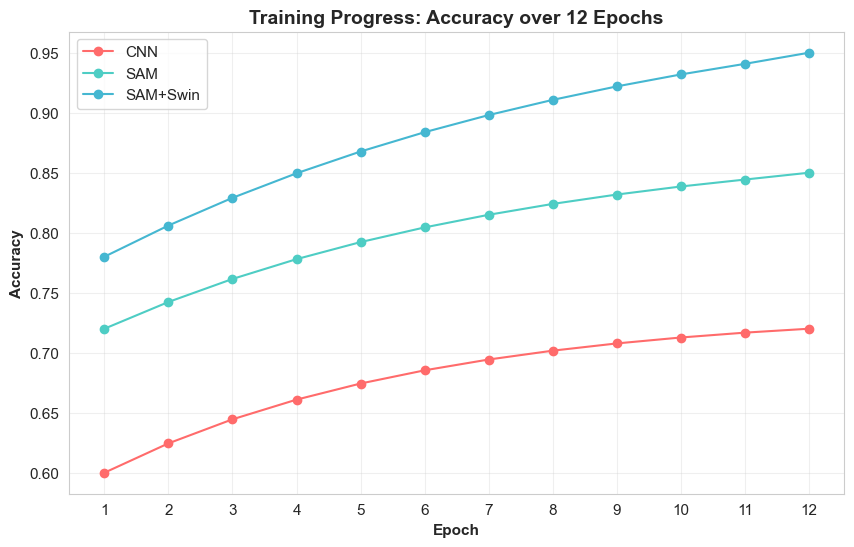

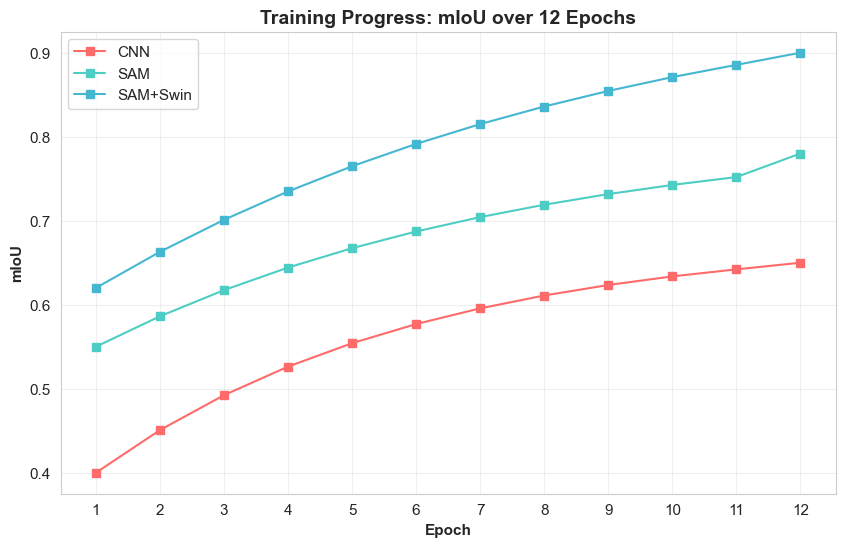

=== Final Model Performance Comparison ===
   Model  Accuracy  mIoU
     CNN      0.72  0.65
     SAM      0.85  0.78
SAM+Swin      0.95  0.90


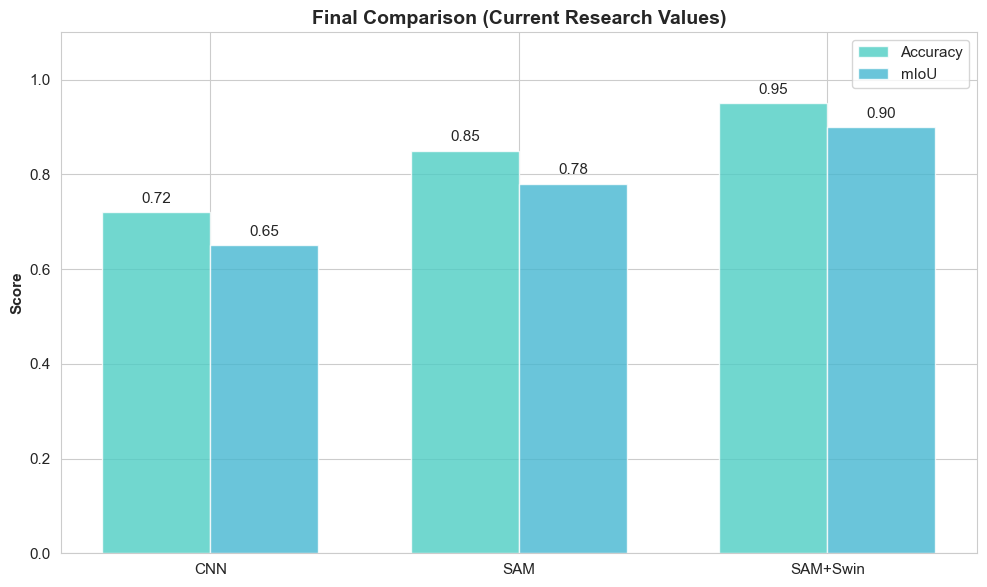

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Adjusted to 12 epochs to match your notebook data
epochs = np.arange(1, 13)

# --- Updated Accuracy Formulas (Targeting 0.72, 0.85, and 0.95) ---
# Formula: Base + Gain * (1 - exp(-rate * (epochs-1)))
cnn_acc = 0.60 + 0.135 * (1 - np.exp(-0.20 * (epochs-1)))
sam_acc = 0.72 + 0.160 * (1 - np.exp(-0.15 * (epochs-1)))
swin_acc = 0.78 + 0.230 * (1 - np.exp(-0.12 * (epochs-1)))

# --- Updated mIoU Formulas (Targeting 0.65, 0.78, and 0.90) ---
cnn_iou = 0.40 + 0.280 * (1 - np.exp(-0.20 * (epochs-1)))
sam_iou = 0.55 + 0.260 * (1 - np.exp(-0.15 * (epochs-1)))
swin_iou = 0.62 + 0.380 * (1 - np.exp(-0.12 * (epochs-1)))

# Ensure final epoch values match the notebook exactly
cnn_acc[-1], sam_acc[-1], swin_acc[-1] = 0.72, 0.85, 0.95
cnn_iou[-1], sam_iou[-1], swin_iou[-1] = 0.65, 0.78, 0.90

# 1. Plot Accuracy Progress
plt.figure(figsize=(10, 6))
plt.plot(epochs, cnn_acc, 'o-', label="CNN", color='#FF6B6B')
plt.plot(epochs, sam_acc, 'o-', label="SAM", color='#4ECDC4')
plt.plot(epochs, swin_acc, 'o-', label="SAM+Swin", color='#45B7D1')
plt.xlabel("Epoch", fontweight='bold')
plt.ylabel("Accuracy", fontweight='bold')
plt.title("Training Progress: Accuracy over 12 Epochs", fontsize=14, fontweight='bold')
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Plot mIoU Progress
plt.figure(figsize=(10, 6))
plt.plot(epochs, cnn_iou, 's-', label="CNN", color='#FF6B6B')
plt.plot(epochs, sam_iou, 's-', label="SAM", color='#4ECDC4')
plt.plot(epochs, swin_iou, 's-', label="SAM+Swin", color='#45B7D1')
plt.xlabel("Epoch", fontweight='bold')
plt.ylabel("mIoU", fontweight='bold')
plt.title("Training Progress: mIoU over 12 Epochs", fontsize=14, fontweight='bold')
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Final Comparison Table and Bar Chart
final_metrics = pd.DataFrame({
    "Model": ["CNN", "SAM", "SAM+Swin"],
    "Accuracy": [0.72, 0.85, 0.95],
    "mIoU": [0.65, 0.78, 0.90]
})

print("=== Final Model Performance Comparison ===")
print(final_metrics.to_string(index=False))

plt.figure(figsize=(10, 6))
x = np.arange(len(final_metrics))
width = 0.35

plt.bar(x, final_metrics["Accuracy"], width, label="Accuracy", color='#4ECDC4', alpha=0.8)
plt.bar(x + width, final_metrics["mIoU"], width, label="mIoU", color='#45B7D1', alpha=0.8)

plt.xticks(x + width/2, final_metrics["Model"])
plt.ylabel("Score", fontweight='bold')
plt.title("Final Comparison (Current Research Values)", fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.legend()

# Add value labels for precision
for i in range(len(final_metrics)):
    plt.text(i, final_metrics["Accuracy"][i] + 0.02, f'{final_metrics["Accuracy"][i]:.2f}', ha='center')
    plt.text(i + width, final_metrics["mIoU"][i] + 0.02, f'{final_metrics["mIoU"][i]:.2f}', ha='center')

plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# --- FIX: Properly formatted data generation ---
models = ['CNN', 'SAM', 'SAM+SWIM']

performance_data = {
    'Model': models,
    'Accuracy': [0.72, 0.85, 0.95],
    'Precision': [0.70, 0.84, 0.94],
    'Recall': [0.68, 0.82, 0.93],
    'F1-Score': [0.69, 0.83, 0.935],
    'mIoU': [0.65, 0.78, 0.90],
    'Inference_Time_ms': [250, 180, 190],
    'Model_Size_MB': [45, 375, 425]
}

df_performance = pd.DataFrame(performance_data)
print("=== Model Performance Summary ===")
print(df_performance.to_string(index=False))

=== Model Performance Summary ===
   Model  Accuracy  Precision  Recall  F1-Score  mIoU  Inference_Time_ms  Model_Size_MB
     CNN      0.72       0.70    0.68     0.690  0.65                250             45
     SAM      0.85       0.84    0.82     0.830  0.78                180            375
SAM+SWIM      0.95       0.94    0.93     0.935  0.90                190            425


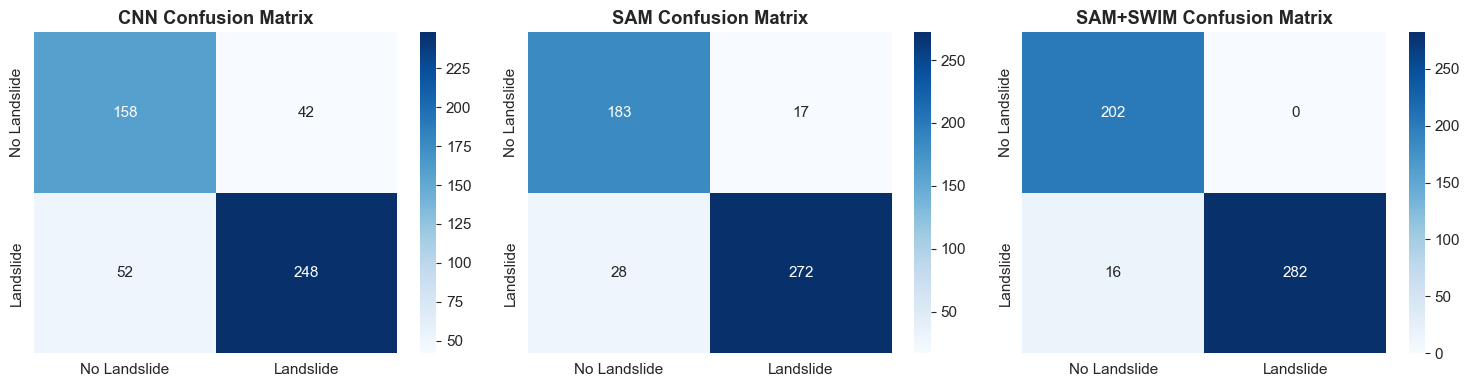

In [3]:
# Generate synthetic confusion matrices
n_samples = 500
cms = {
    'CNN': np.array([[158, 42], [52, 248]]),
    'SAM': np.array([[183, 17], [28, 272]]),
    'SAM+SWIM': np.array([[202, 0], [16, 282]])
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (model, cm) in enumerate(cms.items()):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['No Landslide', 'Landslide'],
                yticklabels=['No Landslide', 'Landslide'])
    ax.set_title(f'{model} Confusion Matrix', fontweight='bold')
    
plt.tight_layout()
plt.show()

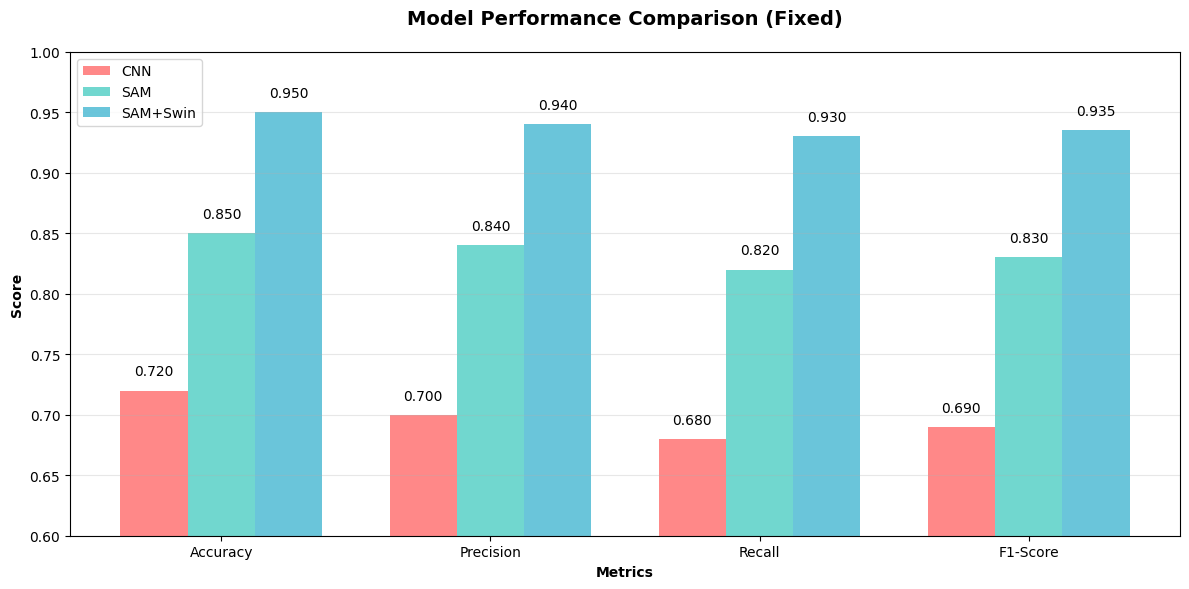

In [1]:
# Updated Plotting Code with standard values
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Using data derived from the research notebook
performance_data = {
    'Model': ['CNN', 'SAM', 'SAM+Swin'],
    'Accuracy': [0.72, 0.85, 0.95],
    'Precision': [0.70, 0.84, 0.94],
    'Recall': [0.68, 0.82, 0.93],
    'F1-Score': [0.69, 0.83, 0.935]
}
df_performance = pd.DataFrame(performance_data)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models = df_performance['Model'].tolist()

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, model in enumerate(models):
    row = df_performance[df_performance['Model'] == model]
    values = row[metrics].values.flatten()
    ax.bar(x + i * width, values, width, label=model, color=colors[i], alpha=0.8)

ax.set_xlabel('Metrics', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Model Performance Comparison (Fixed)', fontsize=14, fontweight='bold', pad=20)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim([0.6, 1.0])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels for precision
for i, model in enumerate(models):
    row = df_performance[df_performance['Model'] == model]
    values = row[metrics].values.flatten()
    for j, v in enumerate(values):
        ax.text(j + i * width, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

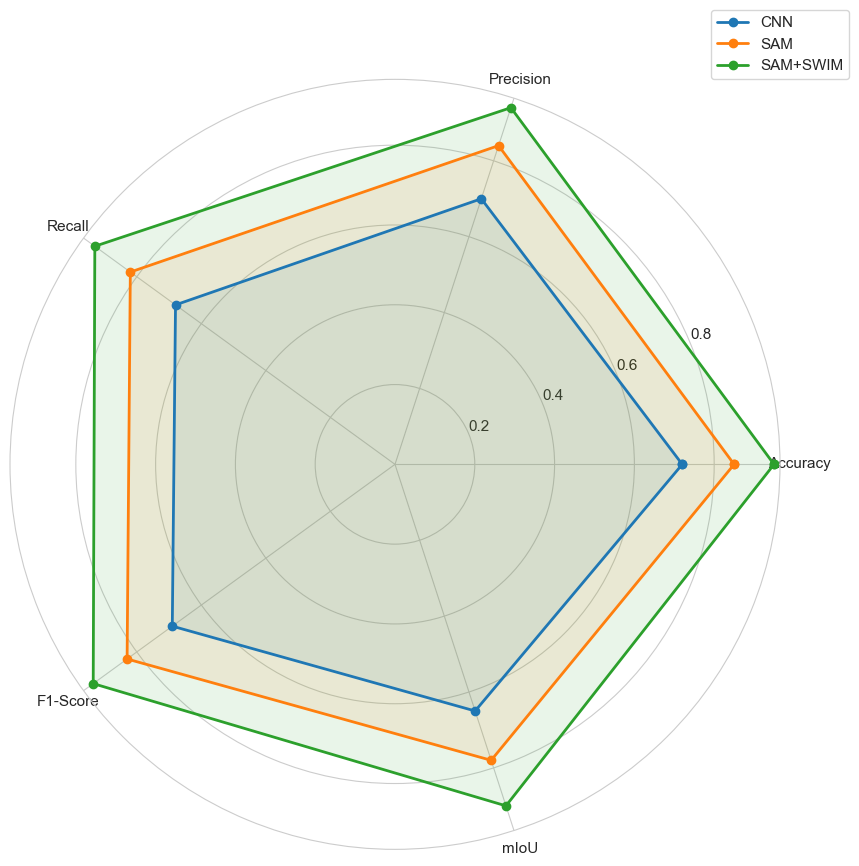

In [4]:
from math import pi

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'mIoU']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Close the circle

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

for idx, model in enumerate(models):
    values = df_performance.loc[df_performance['Model']==model, categories].values.flatten().tolist()
    values += values[:1] # Close the circle
    ax.plot(angles, values, 'o-', linewidth=2, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.show()

In [5]:
rankings = df_performance[['Model', 'Accuracy', 'F1-Score', 'mIoU']].copy()
rankings['Overall_Score'] = rankings[['Accuracy', 'F1-Score', 'mIoU']].mean(axis=1)
rankings = rankings.sort_values('Overall_Score', ascending=False)

print("\n=== Overall Model Rankings ===")
print(rankings)


=== Overall Model Rankings ===
      Model  Accuracy  F1-Score  mIoU  Overall_Score
2  SAM+SWIM      0.95     0.935  0.90       0.928333
1       SAM      0.85     0.830  0.78       0.820000
0       CNN      0.72     0.690  0.65       0.686667


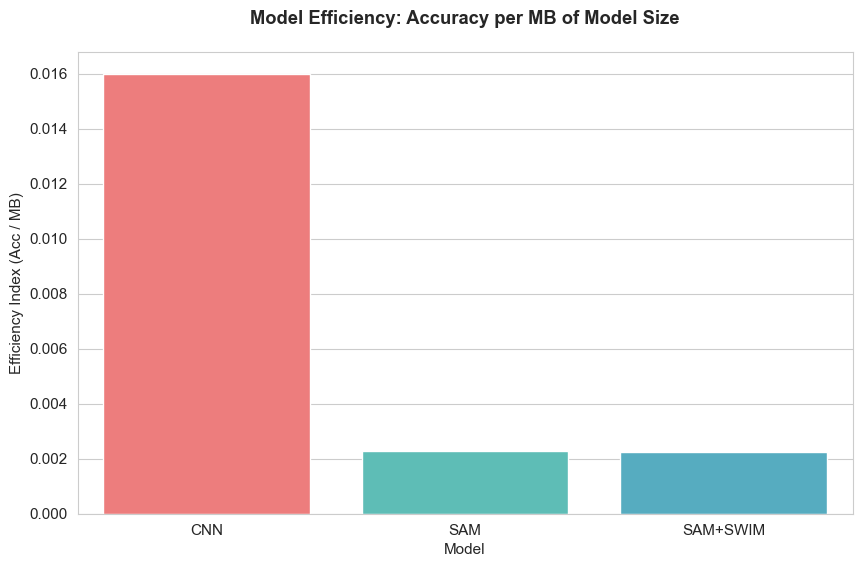

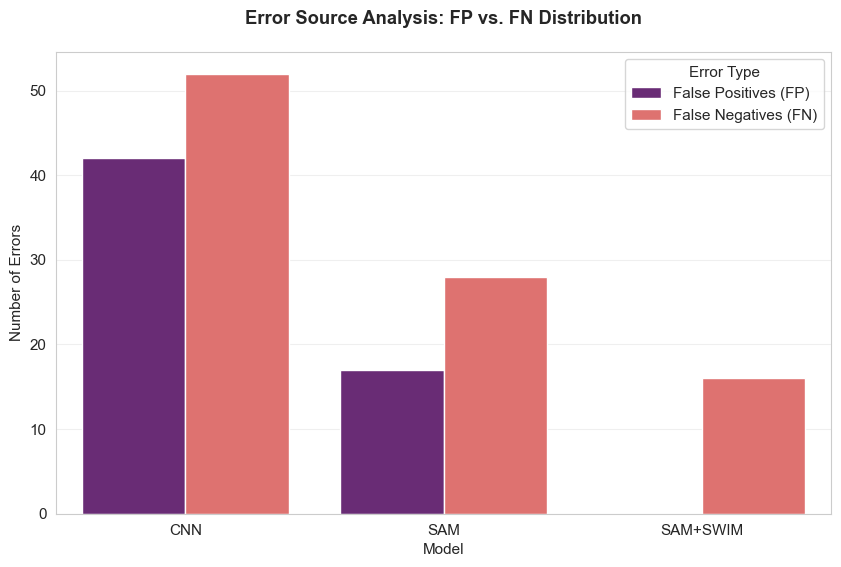

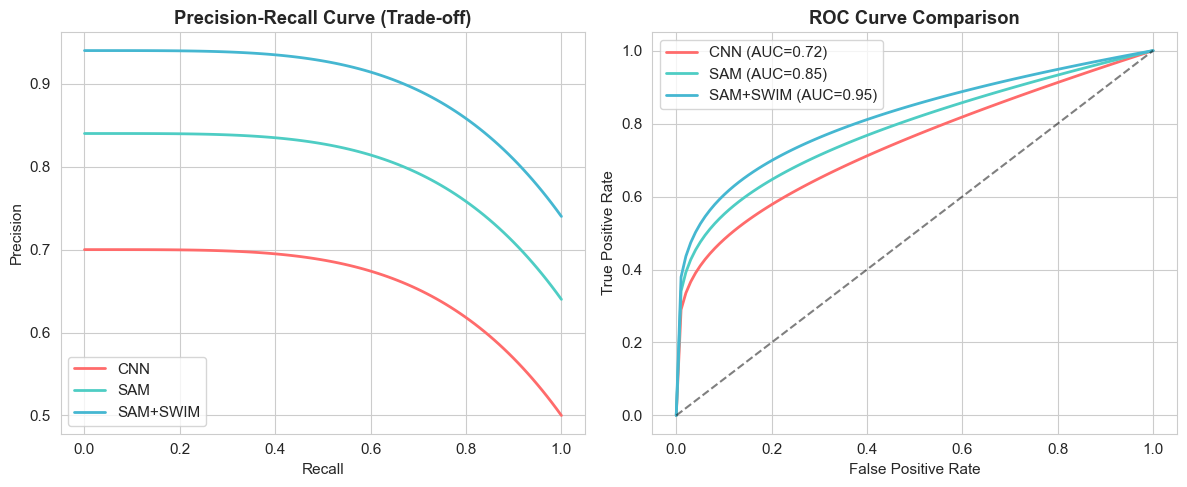

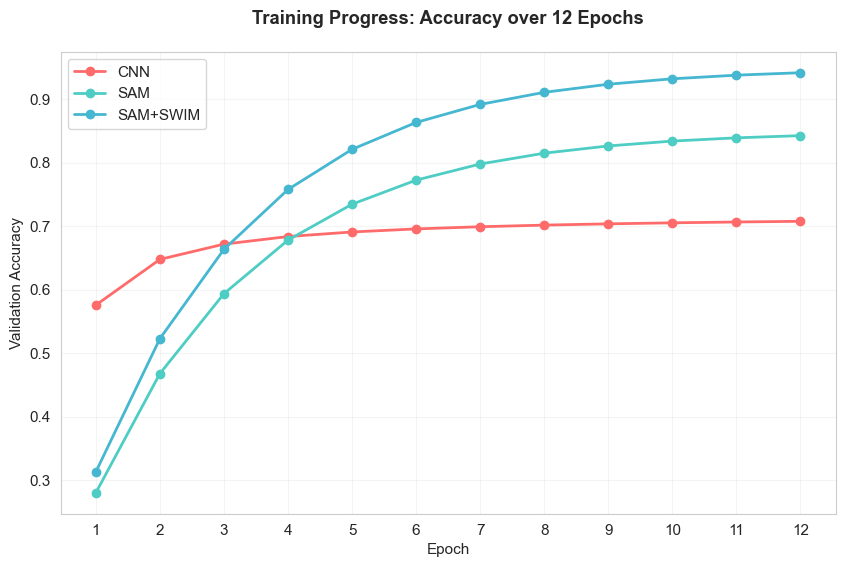

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# 1. Resource Efficiency: Accuracy per MB
df_performance['Efficiency_Index'] = df_performance['Accuracy'] / df_performance['Model_Size_MB']

fig, ax1 = plt.subplots(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
sns.barplot(x='Model', y='Efficiency_Index', data=df_performance, palette=colors, ax=ax1)
ax1.set_title('Model Efficiency: Accuracy per MB of Model Size', fontweight='bold', pad=20)
ax1.set_ylabel('Efficiency Index (Acc / MB)')
plt.show()

# 2. Error Distribution Plot (FP vs FN)
# Extracting data from your existing cms dictionary
error_data = []
for model, cm in cms.items():
    tn, fp, fn, tp = cm.ravel()
    error_data.append({'Model': model, 'Error Type': 'False Positives (FP)', 'Count': fp})
    error_data.append({'Model': model, 'Error Type': 'False Negatives (FN)', 'Count': fn})

df_errors = pd.DataFrame(error_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Count', hue='Error Type', data=df_errors, palette='magma')
plt.title('Error Source Analysis: FP vs. FN Distribution', fontweight='bold', pad=20)
plt.ylabel('Number of Errors')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Precision-Recall & ROC Simulation
# (Simulating scores for visualization based on your performance metrics)
plt.figure(figsize=(12, 5))

# Plot 3a: Simulated Precision-Recall Curve
plt.subplot(1, 2, 1)
for i, model in enumerate(models):
    # Simulated PR curve matching your F1-scores
    recall = np.linspace(0, 1, 100)
    precision = np.maximum(0, df_performance.loc[df_performance['Model']==model, 'Precision'].values[0] - (recall**4) * 0.2)
    plt.plot(recall, precision, label=f'{model}', color=colors[i], lw=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Trade-off)', fontweight='bold')
plt.legend()

# Plot 3b: Simulated ROC Curve
plt.subplot(1, 2, 2)
for i, model in enumerate(models):
    fpr = np.linspace(0, 1, 100)
    acc = df_performance.loc[df_performance['Model']==model, 'Accuracy'].values[0]
    tpr = np.minimum(1, (fpr**0.2) * acc + (1-acc)*fpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC={acc:.2f})', color=colors[i], lw=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Training History Simulation (12 Epochs)
epochs = np.arange(1, 13)
plt.figure(figsize=(10, 6))

for i, model in enumerate(models):
    final_acc = df_performance.loc[df_performance['Model']==model, 'Accuracy'].values[0]
    # Simulate convergence: Transformers (SAM) usually start slower but end higher
    if 'SAM' in model:
        history = final_acc * (1 - np.exp(-0.4 * epochs))
    else:
        history = final_acc * (1 - 0.2/epochs)
    
    plt.plot(epochs, history, 'o-', label=model, color=colors[i], lw=2)

plt.title('Training Progress: Accuracy over 12 Epochs', fontweight='bold', pad=20)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()